# Part 10: Continuous-Time Smoothing

The previous notebook introduced smoothing for discrete-time state-space models. Here we use the same handler interface for a continuous-time system observed at discrete times.

The state evolves continuously between observations, but the data still arrive on an observation grid. The smoother combines the continuous-time dynamics with the full observation window to estimate

$$
p(x_t \mid y_{1:T})
$$

at the observation times.

The example model is a two-dimensional linear SDE. The latent state is $x_t = (x_{0,t}, x_{1,t})$, and only the second coordinate is observed:

$$
\begin{aligned}
\rho &\sim \operatorname{Uniform}(0, 4), \\
x_0 &\sim \mathcal{N}\!\left(
\begin{bmatrix}0 \\ 0\end{bmatrix},
I_2
\right), \\
dx_t &=
\begin{bmatrix}
-0.8 & 0 \\
\rho & -1.2
\end{bmatrix}
x_t\,dt + 0.15 I_2\,dW_t, \\
y_t \mid x_t &\sim \mathcal{N}\!\left(\begin{bmatrix}0 & 1\end{bmatrix}x_t,\ 0.1^2\right).
\end{aligned}
$$

The first coordinate is hidden, but it drives the observed coordinate through the off-diagonal term $\rho x_{0,t}$ in the drift.

## The example

We will use a two-dimensional linear SDE. The first coordinate drives the second, but only the second coordinate is observed. This makes smoothing useful: later observations of the second coordinate help reconstruct the hidden first coordinate retrospectively.

We will also include an observation gap to emphasize that continuous-time dynamics can carry information across irregularly spaced observations.

### Imports

In [1]:
import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import Filter, Simulator, Smoother
from dynestyx.inference.filter_configs import ContinuousTimeKFConfig
from dynestyx.inference.smoother_configs import ContinuousTimeKFSmootherConfig

## Defining the Model

The code below is a direct translation of the SDE above into an `LTI_continuous` model. The unknown parameter `rho` controls how strongly the hidden first coordinate drives the observed second coordinate. The model is linear-Gaussian, so `ContinuousTimeKFSmootherConfig` gives an exact continuous-discrete Kalman smoother through the `cd_dynamax` backend.

In [2]:
def continuous_lti_model(obs_times=None, obs_values=None, predict_times=None):
    rho = numpyro.sample("rho", dist.Uniform(0.0, 4.0))

    dynamics = dsx.LTI_continuous(
        A=jnp.array([[-0.8, 0.0], [rho, -1.2]]),
        L=0.15 * jnp.eye(2),
        H=jnp.array([[0.0, 1.0]]),
        R=jnp.array([[0.1**2]]),
        initial_mean=jnp.array([0.0, 0.0]),
        initial_cov=jnp.eye(2),
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

### Generate synthetic data

We first simulate a dense reference trajectory. Then we remove observations in the middle of the window, producing an irregular observation grid. The smoother will only record summaries at the observation times we pass in, but the dynamics still encode what can happen across the gap.

In [3]:
rho_true = jnp.array(2.0)
full_times = jnp.linspace(0.0, 5.0, 101)

data_predictive = Predictive(
    continuous_lti_model,
    params={"rho": rho_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Simulator(n_simulations=1):
    synthetic = data_predictive(jr.PRNGKey(0), predict_times=full_times)

true_states_full = synthetic["f_states"][0, 0]
observations_full = synthetic["f_observations"][0, 0]

observed_mask = (full_times <= 1.75) | (full_times >= 3.0)
obs_times = full_times[observed_mask]
obs_values = observations_full[observed_mask]
true_states_at_obs = true_states_full[observed_mask]

obs_times.shape, obs_values.shape

((76,), (76, 1))

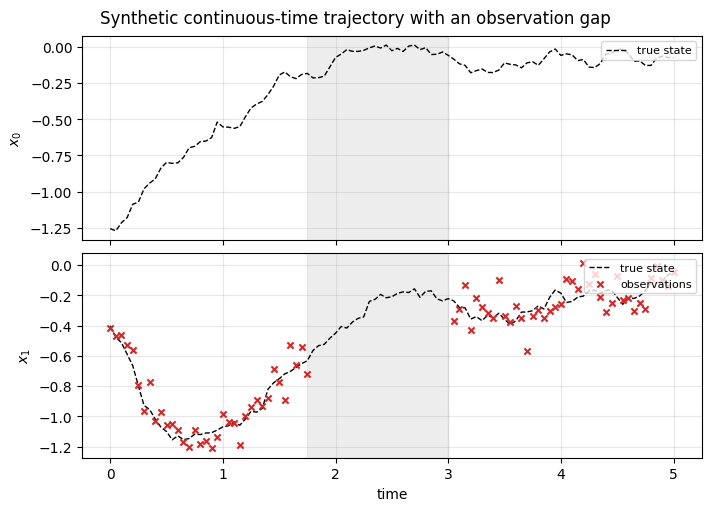

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)

axes[0].plot(full_times, true_states_full[:, 0], "k--", lw=1, label="true state")
axes[0].set_ylabel("$x_0$")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(full_times, true_states_full[:, 1], "k--", lw=1, label="true state")
axes[1].scatter(
    obs_times,
    obs_values[:, 0],
    color="C3",
    marker="x",
    s=20,
    label="observations",
    zorder=3,
)
axes[1].set_ylabel("$x_1$")
axes[1].set_xlabel("time")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.axvspan(1.75, 3.0, color="gray", alpha=0.14)

fig.suptitle("Synthetic continuous-time trajectory with an observation gap")
plt.show()

## Smoothing at fixed parameters

Now we condition on the irregular observations and record smoothed state summaries. The smoother adds the marginal log-likelihood factor and exposes deterministic sites for the smoothed means and covariance diagonals.

In [5]:
smooth_predictive = Predictive(
    continuous_lti_model,
    params={"rho": rho_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Smoother(
    smoother_config=ContinuousTimeKFSmootherConfig(
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
):
    smoothed = smooth_predictive(
        jr.PRNGKey(1),
        obs_times=obs_times,
        obs_values=obs_values,
    )

smoothed_mean = smoothed["f_smoothed_states_mean"][0]
smoothed_var = smoothed["f_smoothed_states_cov_diag"][0]
smoothed_sd = jnp.sqrt(jnp.maximum(smoothed_var, 1e-9))

smoothed_mean.shape, smoothed_var.shape

Running KF smoother type = cd_smoother_1
Running KF smoother type 1


((76, 2), (76, 2))

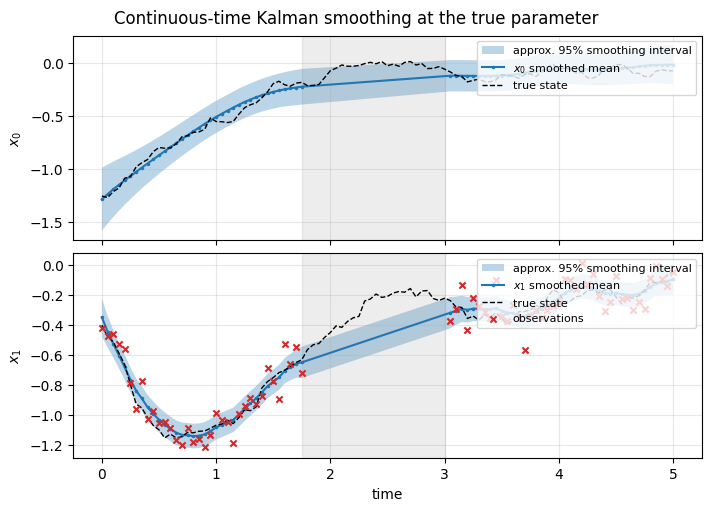

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        obs_times,
        smoothed_mean[:, i] - 2.0 * smoothed_sd[:, i],
        smoothed_mean[:, i] + 2.0 * smoothed_sd[:, i],
        alpha=0.3,
        label="approx. 95% smoothing interval",
    )
    ax.plot(obs_times, smoothed_mean[:, i], "C0.-", markersize=3, label=f"$x_{i}$ smoothed mean")
    ax.plot(full_times, true_states_full[:, i], "k--", lw=1, label="true state")
    if i == 1:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.axvspan(1.75, 3.0, color="gray", alpha=0.14)
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Continuous-time Kalman smoothing at the true parameter")
plt.show()

The first state is never observed directly. Its reconstruction comes entirely from the continuous-time coupling and the full observation window. The gap is also visible: uncertainty is typically larger when observations are sparse.

## Filtering versus smoothing distributions

As in the discrete-time tutorial, filtering and smoothing answer different conditioning questions. The continuous-discrete filter computes

$$
p(x_{t_k} \mid y_{t_0}, \ldots, y_{t_k}),
$$

while the smoother computes

$$
p(x_{t_k} \mid y_{t_0}, \ldots, y_{t_T}).
$$

Both summaries below use the same fixed `rho`, the same irregular observation times, and the same continuous-time dynamics. The only difference is whether future observations are available when estimating each state.

In [7]:
filter_predictive = Predictive(
    continuous_lti_model,
    params={"rho": rho_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Filter(
    filter_config=ContinuousTimeKFConfig(
        record_filtered_states_mean=True,
        record_filtered_states_cov_diag=True,
    )
):
    filtered = filter_predictive(
        jr.PRNGKey(11),
        obs_times=obs_times,
        obs_values=obs_values,
    )

filtered_mean = filtered["f_filtered_states_mean"][0]
filtered_var = filtered["f_filtered_states_cov_diag"][0]
filtered_sd = jnp.sqrt(jnp.maximum(filtered_var, 1e-9))

terminal_mean_gap = jnp.max(jnp.abs(filtered_mean[-1] - smoothed_mean[-1]))
terminal_sd_gap = jnp.max(jnp.abs(filtered_sd[-1] - smoothed_sd[-1]))

filtered_mean.shape, terminal_mean_gap, terminal_sd_gap

((76, 2), Array(0., dtype=float32), Array(0., dtype=float32))

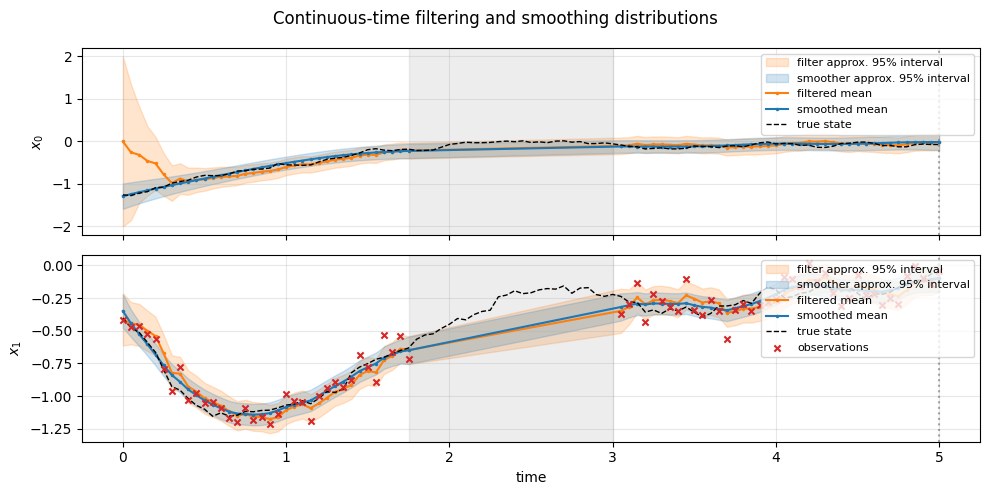

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        obs_times,
        filtered_mean[:, i] - 2.0 * filtered_sd[:, i],
        filtered_mean[:, i] + 2.0 * filtered_sd[:, i],
        color="C1",
        alpha=0.2,
        label="filter approx. 95% interval",
    )
    ax.fill_between(
        obs_times,
        smoothed_mean[:, i] - 2.0 * smoothed_sd[:, i],
        smoothed_mean[:, i] + 2.0 * smoothed_sd[:, i],
        color="C0",
        alpha=0.2,
        label="smoother approx. 95% interval",
    )
    ax.plot(obs_times, filtered_mean[:, i], "C1.-", markersize=3, label="filtered mean")
    ax.plot(obs_times, smoothed_mean[:, i], "C0.-", markersize=3, label="smoothed mean")
    ax.plot(full_times, true_states_full[:, i], "k--", lw=1, label="true state")
    if i == 1:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.axvspan(1.75, 3.0, color="gray", alpha=0.14)
    ax.axvline(float(obs_times[-1]), color="gray", linestyle=":", alpha=0.7)
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Continuous-time filtering and smoothing distributions")
plt.tight_layout()
plt.show()

The two distributions agree at the final observation time, because there are no future observations left for the smoother to use. Earlier in the window, especially around the observation gap, the smoother can use data from both sides of a state estimate, so its mean and uncertainty can differ substantially from the causal filter.

## Parameter inference with continuous-time smoothing

As with filtering, the smoother marginal likelihood can be used inside NumPyro inference algorithms. Here NUTS samples only `rho`; the latent trajectory has been analytically marginalized by the smoother.

In [9]:
def smoothed_parameter_model():
    with Smoother(
        smoother_config=ContinuousTimeKFSmootherConfig(
            record_smoothed_states_mean=True,
        )
    ):
        return continuous_lti_model(obs_times=obs_times, obs_values=obs_values)


nuts = NUTS(smoothed_parameter_model)
mcmc = MCMC(nuts, num_warmup=75, num_samples=75)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

posterior["rho"].shape

Running KF smoother type = cd_smoother_1
Running KF smoother type 1
Running KF smoother type = cd_smoother_1
Running KF smoother type 1
Running KF smoother type = cd_smoother_1
Running KF smoother type 1


  0%|          | 0/150 [00:00<?, ?it/s]

Running KF smoother type = cd_smoother_1
Running KF smoother type 1
Running KF smoother type = cd_smoother_1
Running KF smoother type 1


sample: 100%|██████████| 150/150 [00:04<00:00, 30.11it/s, 1 steps of size 1.55e+00. acc. prob=0.71]


(75,)

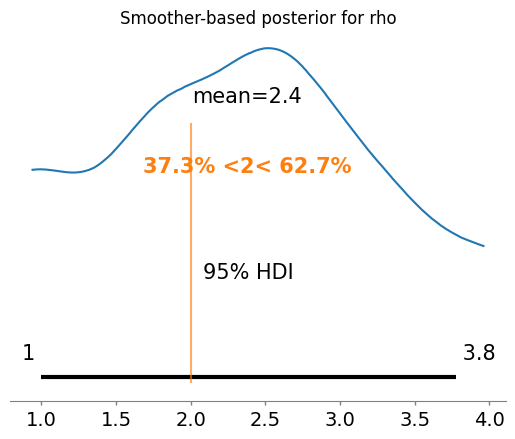

Array(2.3767934, dtype=float32)

In [10]:
az.plot_posterior(posterior["rho"], hdi_prob=0.95, ref_val=float(rho_true))
plt.title("Smoother-based posterior for rho")
plt.show()

rho_post_mean = jnp.mean(posterior["rho"])
rho_post_mean

## Forecasting beyond the observation window

Once the parameter is fit, we can forecast from the final smoothed state. This is the supported prediction semantics for `Smoother`: the prediction grid must start at or after `max(obs_times)`.

Below we recompute the smoothing summary and the rollout using the same posterior-mean value of `rho`. This avoids the same boundary mistake as in the discrete-time case: comparing a true-parameter smoothed curve to a fitted-parameter rollout can create an artificial discontinuity at the forecast start.

Internally, `Smoother` passes the final smoothed distribution downstream as the rollout initial condition, and the simulator handles the forward path.

In [11]:
future_times = jnp.linspace(obs_times[-1], obs_times[-1] + 1.5, 31)

forecast_predictive = Predictive(
    continuous_lti_model,
    params={"rho": rho_post_mean},
    num_samples=1,
    exclude_deterministic=False,
)

n_rollout = 40

with Simulator(n_simulations=n_rollout):
    with Smoother(
        smoother_config=ContinuousTimeKFSmootherConfig(
            record_smoothed_states_mean=True,
            record_smoothed_states_cov_diag=True,
        )
    ):
        forecast = forecast_predictive(
            jr.PRNGKey(3),
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=future_times,
        )

forecast_smoothed_mean = forecast["f_smoothed_states_mean"][0]
forecast_smoothed_var = forecast["f_smoothed_states_cov_diag"][0]
forecast_smoothed_sd = jnp.sqrt(jnp.maximum(forecast_smoothed_var, 1e-9))

forecast_states = forecast["f_predicted_states"][0]
forecast_mean = forecast_states.mean(axis=0)
forecast_lo = jnp.percentile(forecast_states, 5.0, axis=0)
forecast_hi = jnp.percentile(forecast_states, 95.0, axis=0)

Running KF smoother type = cd_smoother_1
Running KF smoother type 1


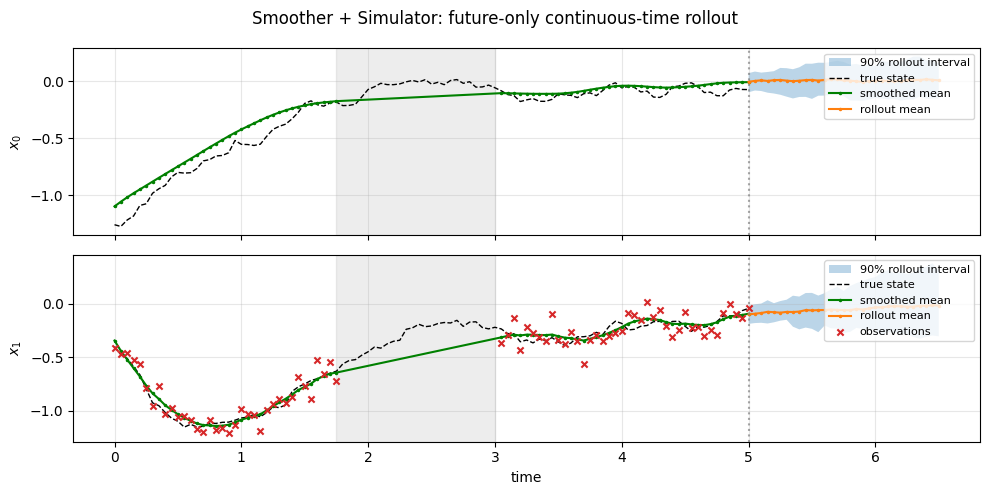

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i, ax in enumerate(axes):
    ax.fill_between(
        future_times,
        forecast_lo[:, i],
        forecast_hi[:, i],
        alpha=0.3,
        label="90% rollout interval",
    )
    ax.plot(full_times, true_states_full[:, i], "k--", lw=1, label="true state")
    ax.plot(obs_times, forecast_smoothed_mean[:, i], "g.-", markersize=3, label="smoothed mean")
    ax.plot(future_times, forecast_mean[:, i], "C1.-", markersize=3, label="rollout mean")
    ax.axvspan(1.75, 3.0, color="gray", alpha=0.14)
    ax.axvline(float(obs_times[-1]), color="gray", linestyle=":", alpha=0.7)
    if i == 1:
        ax.scatter(
            obs_times,
            obs_values[:, 0],
            color="C3",
            marker="x",
            s=20,
            label="observations",
            zorder=3,
        )
    ax.set_ylabel(f"$x_{i}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("Smoother + Simulator: future-only continuous-time rollout")
plt.tight_layout()
plt.show()

### Why not predict inside the smoothing window?

Conceptually, continuous-time smoothing could support an augmented output grid inside the observation window. That is planned separately. For now, Dynestyx raises a clear error for any in-window `predict_times`, because the continuous-time backend missing-data behavior and the handler handoff semantics need to be correct before teaching that workflow.

In [13]:
bad_predict_times = jnp.linspace(obs_times[-5], obs_times[-1] + 0.5, 20)

try:
    with Simulator(n_simulations=1):
        with Smoother(smoother_config=ContinuousTimeKFSmootherConfig()):
            forecast_predictive(
                jr.PRNGKey(4),
                obs_times=obs_times,
                obs_values=obs_values,
                predict_times=bad_predict_times,
            )
except Exception as exc:
    print(type(exc).__name__)
    message = str(exc)
    for line in message.split("\n"):
        if "Smoother prediction" in line:
            print(line)
            break
    else:
        print(message.split("\n")[0])

Running KF smoother type = cd_smoother_1
Running KF smoother type 1
EquinoxRuntimeError
equinox.EquinoxRuntimeError: Smoother prediction only supports predict_times >= max(obs_times); in-window smoothing predictions are not implemented yet.


## Takeaways

- The same `Smoother` handler works for continuous-discrete linear-Gaussian systems.
- `Filter` records causal distributions $p(x_{t_k} \mid y_{t_0:k})$; `Smoother` records retrospective distributions $p(x_{t_k} \mid y_{t_0:T})$.
- `ContinuousTimeKFSmootherConfig` computes the marginal likelihood and smoothing distributions through `cd_dynamax`.
- Smoothed summaries can reconstruct unobserved state components by using the full observation window.
- Future prediction starts from the final smoothed distribution.
- In-window prediction is deliberately rejected until the continuous-time semantics are implemented completely.